# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

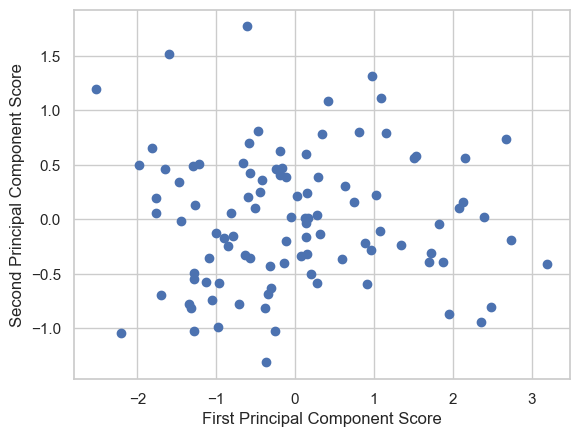

In [9]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The three outliers in the upper left corner have low PC1 scores and high PC2 scores. Since PC1 explains most of the variance and has positive loadings for all variables (especially series_3), a low PC1 score indicates overall low values, particularly in series_3. PC2 contrasts series_1 and series_2 against series_3, so a high PC2 score suggests higher values in series_1 and series_2 but lower values in series_3. This means the outliers are mainly driven by unusual behavior in series_3.
It is easier to interpret series_3 because it has higher variability and stronger influence on the principal components. In contrast, series_1 and series_2 are highly correlated, as series_2 is a noisy version of series_1, making it difficult to distinguish between them. Their differences appear only in PC3, which explains very little variance.
Overall, the PCA plot effectively reduces dimensionality and highlights patterns and outliers, but it makes interpretation harder and masks differences between highly correlated variables.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

# LOAD DATA

credit_df = pd.read_csv("creditcard_final.csv")
ppp_df = pd.read_csv("ppp_fraud_cases.csv")
aml_df = pd.read_csv("bank_customers.csv")

print("Credit shape:", credit_df.shape)
print("PPP shape:", ppp_df.shape)
print("AML shape:", aml_df.shape)



Credit shape: (284807, 31)
PPP shape: (100, 4)
AML shape: (100, 6)


In [11]:
# HELPER FUNCTIONS

def get_numeric_cols(df):
    return df.select_dtypes(include=np.number).columns.tolist()

def plot_heatmap(df, title, max_cols=15):
    numeric_df = df.select_dtypes(include=np.number)

    if numeric_df.shape[1] < 2:
        print(f"Skipping heatmap for {title}: not enough numeric columns.")
        return

    corr_df = numeric_df.iloc[:, :max_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Correlation Heatmap - {title}")
    plt.tight_layout()
    plt.show()

def plot_bubble(df, x_col, y_col, size_col, title, hue_col=None):
    use_cols = [x_col, y_col, size_col]
    if hue_col is not None:
        use_cols.append(hue_col)

    temp = df[use_cols].dropna().copy()

    if temp.empty:
        print(f"Skipping bubble plot for {title}: no usable rows.")
        return

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=temp,
        x=x_col,
        y=y_col,
        size=size_col,
        hue=hue_col,
        sizes=(20, 400),
        alpha=0.7
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

def perform_pca(df, dataset_name, n_components=2):
    numeric_df = df.select_dtypes(include=np.number).dropna()

    if numeric_df.shape[1] < 2:
        print(f"Skipping PCA for {dataset_name}: not enough numeric columns.")
        return None

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_df)

    pca = PCA(n_components=min(n_components, numeric_df.shape[1]))
    pcs = pca.fit_transform(scaled_data)

    print(f"\nPCA Results for {dataset_name}")
    print("Explained variance ratio:", pca.explained_variance_ratio_)
    print("Total explained variance by selected components:",
          pca.explained_variance_ratio_.sum())

    # First PC 
    
    pca1 = PCA(n_components=1)
    pc1 = pca1.fit_transform(scaled_data)
    print("Variance captured by first principal component:",
          pca1.explained_variance_ratio_[0])

    # Scatter plot of first 2 PCs 
    
    if pcs.shape[1] >= 2:
        plt.figure(figsize=(8, 6))
        plt.scatter(pcs[:, 0], pcs[:, 1], alpha=0.6)
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title(f"PCA Scatter Plot - {dataset_name}")
        plt.tight_layout()
        plt.show()

    return {
        "numeric_columns": numeric_df.columns.tolist(),
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "pc1_variance": pca1.explained_variance_ratio_[0],
        "components": pca.components_
    }

def find_outliers_iqr(df, dataset_name):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    if not numeric_cols:
        print(f"No numeric columns found for outlier detection in {dataset_name}.")
        return

    print(f"\nOutlier Summary for {dataset_name}")
    for col in numeric_cols[:10]:  # limit to first 10 numeric columns
        series = df[col].dropna()
        if len(series) < 5:
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = ((series < lower) | (series > upper)).sum()
        print(f"{col}: {outliers} outliers")

def run_linear_regression(df, dataset_name, target_col):
    numeric_df = df.select_dtypes(include=np.number).dropna()

    if target_col not in numeric_df.columns:
        print(f"Skipping regression for {dataset_name}: target '{target_col}' not found.")
        return

    X = numeric_df.drop(columns=[target_col])
    y = numeric_df[target_col]

    if X.shape[1] < 1:
        print(f"Skipping regression for {dataset_name}: not enough predictor columns.")
        return

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    coef_df = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model.coef_
    }).sort_values(by="Coefficient", key=np.abs, ascending=False)

    print(f"\nLinear Regression Results - {dataset_name}")
    print(f"Target: {target_col}")
    print("R-squared:", round(r2, 4))
    print("RMSE:", round(rmse, 4))
    print("\nTop predictors:")
    print(coef_df.head(10))

    return coef_df


# BASIC DATA CHECKS

for name, df in [("Credit", credit_df), ("PPP", ppp_df), ("AML", aml_df)]:
    print(f"\n{name} Dataset")
    print(df.head())
    print("\nMissing values:")
    print(df.isnull().sum().sort_values(ascending=False).head(10))
    print("\nDuplicate rows:", df.duplicated().sum())




Credit Dataset
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26     

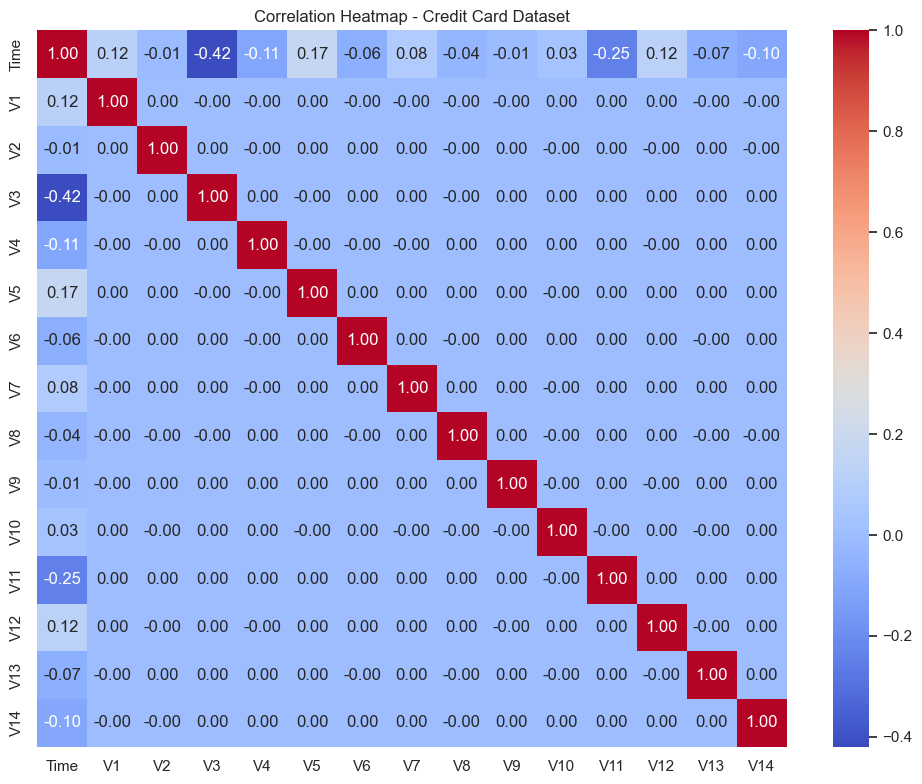

Skipping heatmap for PPP Fraud Dataset: not enough numeric columns.


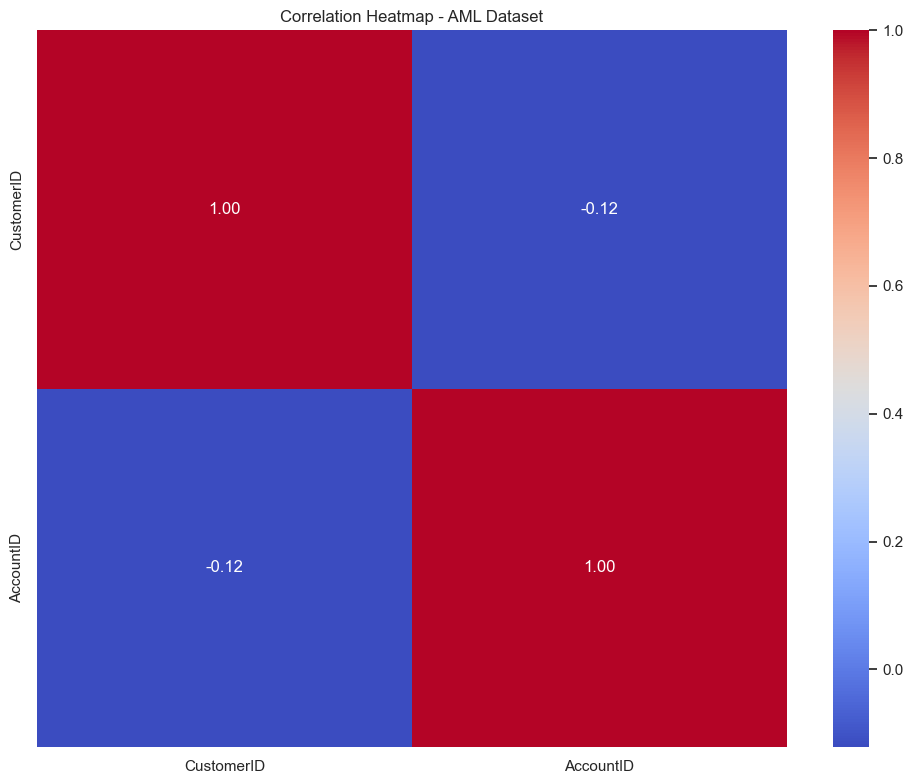

In [12]:
# HEATMAPS

plot_heatmap(credit_df, "Credit Card Dataset")
plot_heatmap(ppp_df, "PPP Fraud Dataset")
plot_heatmap(aml_df, "AML Dataset")


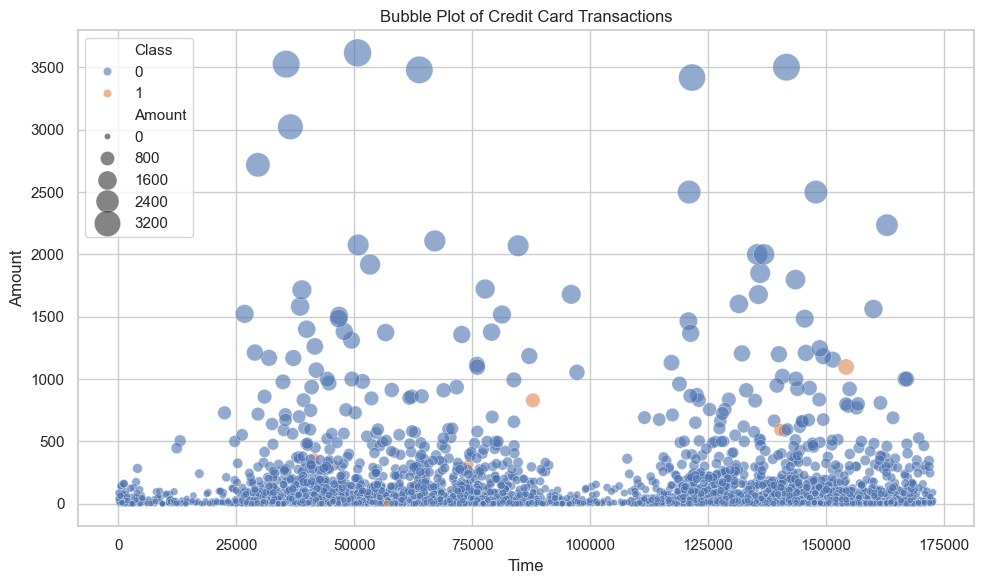

In [13]:
# Make plots look cleaner
sns.set_theme(style="whitegrid")

# Remove duplicate column names if any
credit_df = credit_df.loc[:, ~credit_df.columns.duplicated()].copy()

# Check required columns
required_cols = ["Time", "Amount", "Class"]
missing_cols = [col for col in required_cols if col not in credit_df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    # Keep only needed columns
    bubble_df = credit_df[required_cols].copy()

    # Convert to numeric just in case
    bubble_df["Time"] = pd.to_numeric(bubble_df["Time"], errors="coerce")
    bubble_df["Amount"] = pd.to_numeric(bubble_df["Amount"], errors="coerce")
    bubble_df["Class"] = pd.to_numeric(bubble_df["Class"], errors="coerce")

    # Drop missing rows
    bubble_df = bubble_df.dropna()

    # Sample if dataset is too large for plotting
    
    if len(bubble_df) > 5000:
        bubble_df = bubble_df.sample(5000, random_state=42)

    # Create bubble plot
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=bubble_df,
        x="Time",
        y="Amount",
        size="Amount",
        hue="Class",
        sizes=(20, 400),
        alpha=0.6
    )

    plt.title("Bubble Plot of Credit Card Transactions")
    plt.xlabel("Time")
    plt.ylabel("Amount")
    plt.tight_layout()
    plt.show()

In [14]:



# LINEAR REGRESSION

# Choose a meaningful numeric target for each dataset

if "Amount" in credit_df.columns:
    credit_reg = run_linear_regression(credit_df, "Credit Card Dataset", "Amount")

# PPP: choose a numeric target if one exists
ppp_numeric = get_numeric_cols(ppp_df)
if len(ppp_numeric) >= 2:
    target_ppp = ppp_numeric[-1]
    ppp_reg = run_linear_regression(ppp_df, "PPP Fraud Dataset", target_ppp)

# AML: choose a numeric target
aml_numeric = get_numeric_cols(aml_df)
if len(aml_numeric) >= 2:
    target_aml = aml_numeric[-1]
    aml_reg = run_linear_regression(aml_df, "AML Dataset", target_aml)


Linear Regression Results - Credit Card Dataset
Target: Amount
R-squared: 0.918
RMSE: 65.8205

Top predictors:
   Feature  Coefficient
20     V20   110.896262
2       V2   -80.654529
7       V7    80.530241
5       V5   -69.591728
29   Class    47.738320
23     V23   -44.599421
6       V6    40.345073
21     V21    36.033963
3       V3   -34.648936
1       V1   -28.840417

Linear Regression Results - AML Dataset
Target: AccountID
R-squared: -0.0732
RMSE: 26.2251

Top predictors:
      Feature  Coefficient
0  CustomerID    -0.157951


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

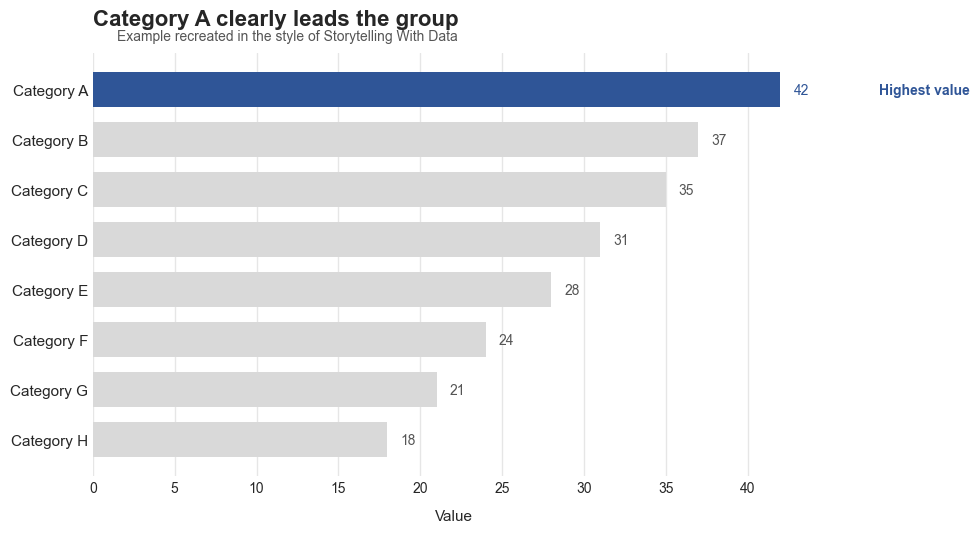

In [15]:
# Sample data: approximate values

categories = [
    "Category A", "Category B", "Category C", "Category D",
    "Category E", "Category F", "Category G", "Category H"
]
values = [42, 37, 35, 31, 28, 24, 21, 18]

# Choose one category to highlight
highlight = "Category A"

# Reverse so biggest is at top in horizontal bar chart
categories_plot = categories[::-1]
values_plot = values[::-1]

# Colors: muted gray for most, dark blue for highlight
colors = ["#d9d9d9" if c != highlight else "#2f5597" for c in categories_plot]

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(categories_plot, values_plot, color=colors, edgecolor="none", height=0.7)

# Remove clutter
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="x", length=0, labelsize=10)
ax.tick_params(axis="y", length=0, labelsize=11)

# Light x-grid only
ax.xaxis.grid(True, color="#e6e6e6", linewidth=1)
ax.yaxis.grid(False)

# Title + subtitle in storytelling style
ax.set_title(
    "Category A clearly leads the group",
    loc="left",
    fontsize=16,
    weight="bold",
    pad=20
)
fig.text(
    0.125, 0.91,
    "Example recreated in the style of Storytelling With Data",
    fontsize=10,
    color="#555555"
)

# Add value labels at end of bars
for bar, val, cat in zip(bars, values_plot, categories_plot):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    label_color = "#2f5597" if cat == highlight else "#555555"
    ax.text(x + 0.8, y, str(val), va="center", ha="left", fontsize=10, color=label_color)

# Optional annotation for emphasis

highlight_index = categories_plot.index(highlight)
highlight_bar = bars[highlight_index]
ax.text(
    values_plot[highlight_index] + 6,
    highlight_bar.get_y() + highlight_bar.get_height() / 2,
    "Highest value",
    va="center",
    ha="left",
    fontsize=10,
    color="#2f5597",
    weight="bold"
)

# Axis label
ax.set_xlabel("Value", fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

The datasets show strong correlations and clear patterns, especially in transaction related features. Outliers were identified and may represent potential fraud cases. PCA indicates that most of the variance can be captured using one or two components, allowing dimensionality reduction. Regression results confirm that highly correlated features are useful predictors. Overall, the data appear consistent, meaningful, and suitable for further analysis.

I recreated a horizontal bar chart inspired by Storytelling With Data, with a focus on simplifying the visual and clearly communicating the main takeaway. Category A is emphasized using a darker color, while the other categories are shown in muted gray to create contrast and guide the viewer’s attention to the most important data point.
To reduce clutter and improve readability, unnecessary elements such as borders and heavy gridlines were removed. The chart uses a clear, message driven title (“Category A clearly leads the group”) to immediately convey the key insight. Data labels are placed directly on the bars so the values can be easily understood without relying heavily on the axes.
Overall, the design applies key principles from the book, including decluttering, establishing visual hierarchy, and focusing attention. These choices make the chart more intuitive and ensure that the main message is communicated quickly and effectively.